<a href="https://colab.research.google.com/github/tasyadwi12/FP-WTB/blob/main/decision_tree_penyakit_padi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile
import numpy as np
import cv2
import gdown

print("1. Mengunduh data langsung dari folder Google Drive Kelompok...")
folder_id = '1J5DuzOX-D-xYL4kBX07iiWLh0dm-kB-2'

os.makedirs('/content/dataset_downloaded', exist_ok=True)
if not os.listdir('/content/dataset_downloaded'):
    try:
        gdown.download_folder(id=folder_id, output='/content/dataset_downloaded', quiet=False, remaining_ok=True)
        print("-> Sukses mengunduh seluruh isi folder Drive!")
    except Exception as e:
        print(f"Gagal mengunduh folder: {e}")
else:
    print("-> Data sudah terunduh sebelumnya, langsung lanjut ke ekstraksi.")

print("\n2. Mengekstrak semua file ZIP yang berhasil ditemukan...")
os.makedirs('/content/dataset_final_terbongkar', exist_ok=True)

for root, dirs, files in os.walk('/content/dataset_downloaded'):
    for file in files:
        if file.lower().endswith('.zip'):
            path_zip = os.path.join(root, file)
            try:
                with zipfile.ZipFile(path_zip, 'r') as zip_ref:
                    zip_ref.extractall('/content/dataset_final_terbongkar')
                print(f" -> Sukses membongkar file ZIP: {file}")
            except Exception as e:
                print(f" -> Gagal mengekstrak {file}: {e}")

print("\n3. Membaca gambar daun padi dengan metode pembagian kelas pasti...")
IMG_SIZE = 224
CATEGORIES = ['BERCAK COKLAT', 'BLAST', 'DAUN SEHAT', 'HAWAR DAUN BAKTERI']
data = []
labels = []
counts = {cat: 0 for cat in CATEGORIES}

for root, dirs, files in os.walk('/content/dataset_final_terbongkar'):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            jalur_full_upper = os.path.join(root, file).upper()

            # Deteksi kelas utama yang namanya sudah pasti
            if 'BERCAK' in jalur_full_upper or 'COKLAT' in jalur_full_upper:
                kategori_terpilih = 'BERCAK COKLAT'
            elif 'BLAST' in jalur_full_upper:
                kategori_terpilih = 'BLAST'
            elif 'SEHAT' in jalur_full_upper:
                kategori_terpilih = 'DAUN SEHAT'
            else:
                # SAPU BERSIH: Semua gambar sisa otomatis masuk ke Hawar Daun Bakteri
                kategori_terpilih = 'HAWAR DAUN BAKTERI'

            class_num = CATEGORIES.index(kategori_terpilih)
            try:
                img_path = os.path.join(root, file)
                img_array = cv2.imread(img_path)
                if img_array is None:
                    continue
                img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                data.append(resized_array)
                labels.append(class_num)
                counts[kategori_terpilih] += 1
            except Exception as e:
                pass

print("\nHasil pengumpulan data akhir kelompok Anda:")
for cat in CATEGORIES:
    print(f" - {cat}: {counts[cat]} gambar berhasil dimuat")

X = np.array(data)
y = np.array(labels)

if len(X) > 0:
    X = X / 255.0
    print(f"\n[SUKSES GLOBAL] Berhasil menyatukan total {X.shape[0]} gambar ke memori!")
    print(f"Ukuran akhir matriks data Anda: {X.shape}")
else:
    print("\n[EROR] Gambar tidak ditemukan.")

1. Mengunduh data langsung dari folder Google Drive Kelompok...
-> Data sudah terunduh sebelumnya, langsung lanjut ke ekstraksi.

2. Mengekstrak semua file ZIP yang berhasil ditemukan...
 -> Sukses membongkar file ZIP: DAUN SEHAT.zip
 -> Sukses membongkar file ZIP: Kelompok 19-Hawar Daaun Padi 2.zip
 -> Sukses membongkar file ZIP: PENYAKIT HAWAR DAUN PADI.zip
 -> Sukses membongkar file ZIP: BERCAK COKLAT.zip
 -> Sukses membongkar file ZIP: BLAST.zip

3. Membaca gambar daun padi dengan metode pembagian kelas pasti...

Hasil pengumpulan data akhir kelompok Anda:
 - BERCAK COKLAT: 443 gambar berhasil dimuat
 - BLAST: 403 gambar berhasil dimuat
 - DAUN SEHAT: 500 gambar berhasil dimuat
 - HAWAR DAUN BAKTERI: 251 gambar berhasil dimuat

[SUKSES GLOBAL] Berhasil menyatukan total 1597 gambar ke memori!
Ukuran akhir matriks data Anda: (1597, 224, 224, 3)


In [ ]:
# =========================================================
# Jembatan Fitur: Mengubah Gambar Menjadi Angka (VGG16)
# =========================================================

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
import numpy as np

print("Memuat arsitektur VGG16 untuk ekstraksi fitur numerik...")
# Memuat model VGG16 bawaan Google Colab
base_model = VGG16(weights='imagenet', include_top=True)
model_ekstraksi = Model(inputs=base_model.input, outputs=base_model.get_layer('fc2').output)

print("\nSedang mengonversi 1.597 gambar menjadi matriks fitur...")
# Preprocessing skala standar untuk VGG16
X_vgg = X * 255.0
X_vgg = preprocess_input(X_vgg)

# Membuat variabel 'features' yang dicari oleh Decision Tree Anda
features = model_ekstraksi.predict(X_vgg, batch_size=32, verbose=1)

print(f"\n[SUKSES] Variabel 'features' berhasil dibuat dengan dimensi: {features.shape}")
print("Sekarang Anda sudah bisa menjalankan sel Decision Tree di bawahnya!")

Memuat arsitektur VGG16 untuk ekstraksi fitur numerik...
553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step

Sedang mengonversi 1.597 gambar menjadi matriks fitur...
50/50 ━━━━━━━━━━━━━━━━━━━━ 988s 20s/step

[SUKSES] Variabel 'features' berhasil dibuat dengan dimensi: (1597, 4096)
Sekarang Anda sudah bisa menjalankan sel Decision Tree di bawahnya!


In [ ]:
# =========================================================
# Analisis Komparatif: SVM vs Random Forest vs Decision Tree
# =========================================================

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Bagi data VGG16 menjadi Data Training (80%) dan Data Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2, random_state=42)

print("Memulai proses pelatihan 3 algoritma sekaligus...\n")

# 2. Inisialisasi Ketiga Model
model_dt = DecisionTreeClassifier(random_state=42)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_svm = SVC(kernel='linear', random_state=42)

# 3. Melatih Model (Fit)
print("-> Melatih Decision Tree...")
model_dt.fit(X_train, y_train)

print("-> Melatih Random Forest...")
model_rf.fit(X_train, y_train)

print("-> Melatih Support Vector Machine (SVM)...")
model_svm.fit(X_train, y_train)

# 4. Melakukan Prediksi
pred_dt = model_dt.predict(X_test)
pred_rf = model_rf.predict(X_test)
pred_svm = model_svm.predict(X_test)

# 5. Hitung Skor Akurasi
aku_dt = accuracy_score(y_test, pred_dt) * 100
aku_rf = accuracy_score(y_test, pred_rf) * 100
aku_svm = accuracy_score(y_test, pred_svm) * 100

# 6. Tampilkan Tabel Perbandingan Final untuk PPT
print("\n" + "="*45)
print("     TABEL PERBANDINGAN AKURASI KELOMPOK")
print("="*45)

hasil_komparasi = pd.DataFrame({
    'Algoritma Klasifikasi': ['Decision Tree (DT)', 'Random Forest (RF)', 'Support Vector Machine (SVM)'],
    'Skor Akurasi (%)': [f"{aku_dt:.2f}%", f"{aku_rf:.2f}%", f"{aku_svm:.2f}%"]
})

print(hasil_komparasi.to_string(index=False))
print("="*45)
print("\nKesimpulan: Algoritma terbaik untuk dataset kelompok kami adalah",
      hasil_komparasi.iloc[pd.Series([aku_dt, aku_rf, aku_svm]).idxmax()]['Algoritma Klasifikasi'])

Memulai proses pelatihan 3 algoritma sekaligus...

-> Melatih Decision Tree...
-> Melatih Random Forest...
-> Melatih Support Vector Machine (SVM)...

     TABEL PERBANDINGAN AKURASI KELOMPOK
       Algoritma Klasifikasi Skor Akurasi (%)
          Decision Tree (DT)           82.19%
          Random Forest (RF)           95.31%
Support Vector Machine (SVM)           96.56%

Kesimpulan: Algoritma terbaik untuk dataset kelompok kami adalah Support Vector Machine (SVM)


In [ ]:
# =========================================================
# 1. MENAMPILKAN STRUKTUR DATASET (Seperti Contoh Iris)
# =========================================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Mengubah matriks fitur numerik VGG16 menjadi DataFrame Pandas
nama_kolom_fitur = [f"Fitur_{i+1}" for i in range(features.shape[1])]
df = pd.DataFrame(features, columns=nama_kolom_fitur)

# Menambahkan label target numerik dan nama kategorinya
df['target'] = y
CATEGORIES = ['BERCAK COKLAT', 'BLAST', 'DAUN SEHAT', 'HAWAR DAUN BAKTERI']
df['nama_kategori'] = df['target'].map(lambda x: CATEGORIES[x])

print(f"=== STRUKTUR DATASET KELOMPOK (Total: {df.shape[0]} Gambar) ===")
# Menampilkan 5 baris pertama dataset seperti df.head() pada contoh Anda
display(df.head())
print("\n" + "="*50 + "\n")

# =========================================================
# 2. PROSES KLASIFIKASI & KOMPARASI ALGORITMA
# =========================================================
# Memisahkan data kembali menjadi training (80%) dan testing (20%)
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2, random_state=42)

print("Memulai proses pelatihan 3 algoritma sekaligus...\n")

# Inisialisasi Model
model_dt = DecisionTreeClassifier(random_state=42)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_svm = SVC(kernel='linear', random_state=42)

# Melatih Model (Fit)
print("-> Melatih Decision Tree...")
model_dt.fit(X_train, y_train)

print("-> Melatih Random Forest...")
model_rf.fit(X_train, y_train)

print("-> Melatih Support Vector Machine (SVM)...")
model_svm.fit(X_train, y_train)

# Melakukan Prediksi untuk evaluasi
pred_dt = model_dt.predict(X_test)
pred_rf = model_rf.predict(X_test)
pred_svm = model_svm.predict(X_test)

# Menghitung Persentase Akurasi
aku_dt = accuracy_score(y_test, pred_dt) * 100
aku_rf = accuracy_score(y_test, pred_rf) * 100
aku_svm = accuracy_score(y_test, pred_svm) * 100

# Menampilkan Tabel Hasil Akhir Komparasi
print("\n" + "="*45)
print("     TABEL PERBANDINGAN AKURASI FINAL")
print("="*45)

hasil_komparasi = pd.DataFrame({
    'Algoritma Klasifikasi': ['Decision Tree (DT)', 'Random Forest (RF)', 'Support Vector Machine (SVM)'],
    'Skor Akurasi (%)': [f"{aku_dt:.2f}%", f"{aku_rf:.2f}%", f"{aku_svm:.2f}%"]
})

print(hasil_komparasi.to_string(index=False))
print("="*45)

# Menampilkan Kesimpulan Otomatis
terbaik_idx = pd.Series([aku_dt, aku_rf, aku_svm]).idxmax()
algoritma_terbaik = hasil_komparasi.iloc[terbaik_idx]['Algoritma Klasifikasi']
print(f"\nKesimpulan: Algoritma terbaik untuk klasifikasi penyakit daun padi kelompok kami adalah {algoritma_terbaik}")

=== STRUKTUR DATASET KELOMPOK (Total: 1597 Gambar) ===


,Fitur_1,Fitur_2,Fitur_3,Fitur_4,Fitur_5,Fitur_6,Fitur_7,Fitur_8,Fitur_9,Fitur_10,...,Fitur_4089,Fitur_4090,Fitur_4091,Fitur_4092,Fitur_4093,Fitur_4094,Fitur_4095,Fitur_4096,target,nama_kategori
0,0.0,0.0,0.0,0.000000,1.682170,0.000000,0.351696,0.000000,0.228743,0.0,...,2.834240,0.000000,0.000000,0.000000,4.799699,0.000000,0.000000,0.000000,3,HAWAR DAUN BAKTERI
1,0.0,0.0,0.0,0.000000,0.000000,0.397666,0.000000,0.000000,0.786805,0.0,...,0.320130,0.344669,1.921957,0.185020,3.730044,0.000000,0.188819,1.082284,3,HAWAR DAUN BAKTERI
2,0.0,0.0,0.0,0.000000,0.733995,0.000000,0.000000,0.370495,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,1.714205,0.000000,1.297399,0.000000,3,HAWAR DAUN BAKTERI
3,0.0,0.0,0.0,2.199772,1.092904,0.000000,1.432706,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.305124,0.461924,0.554718,0.000000,0.018477,3,HAWAR DAUN BAKTERI
4,0.0,0.0,0.0,0.540314,0.980033,0.000000,0.000000,0.000000,0.190759,0.0,...,2.877728,0.000000,0.000000,0.553078,4.268141,0.000000,0.000000,0.611064,3,HAWAR DAUN BAKTERI




Memulai proses pelatihan 3 algoritma sekaligus...

-> Melatih Decision Tree...
-> Melatih Random Forest...
-> Melatih Support Vector Machine (SVM)...

     TABEL PERBANDINGAN AKURASI FINAL
       Algoritma Klasifikasi Skor Akurasi (%)
          Decision Tree (DT)           82.19%
          Random Forest (RF)           95.31%
Support Vector Machine (SVM)           96.56%

Kesimpulan: Algoritma terbaik untuk klasifikasi penyakit daun padi kelompok kami adalah Support Vector Machine (SVM)


In [ ]:
# =========================================================
# EKSPLORASI DATASET SESUAI MATERI DOSEN
# =========================================================

print("=== 1. MENAMPILKAN 10 DATA PERTAMA (df.head(10)) ===")
display(df.head(10))
print("\n" + "="*60 + "\n")


print("=== 2. MENAMPILKAN 10 DATA TERAKHIR (df.tail(10)) ===")
display(df.tail(10))
print("\n" + "="*60 + "\n")


print("=== 3. RANGKUMAN INFO DATASET (df.info()) ===")
# Menampilkan info terstruktur agar tidak penuh sesak 4096 kolom
print(f"Tipe Data Objek DataFrame: {type(df)}")
print(f"Total Baris Data (Sampel): {df.shape[0]} gambar")
print(f"Total Kolom Fitur + Target: {df.shape[1]} kolom")
print(f"Rincian Memori Penggunaan: {df.memory_usage().sum() / 1024**2:.2f} MB")
print("\nBentuk ringkas struktur data:")
df.info(max_cols=10) # Membatasi tampilan preview kolom agar Colab tetap ringan
print("\n" + "="*60 + "\n")


print("=== 4. STATISTIK DESKRIPTIF DATASET (df.describe()) ===")
# Menampilkan statistik deskriptif untuk beberapa fitur contoh dan target utama
kolom_sampel = ['Fitur_1', 'Fitur_2', 'Fitur_3', 'target']
display(df[kolom_sampel].describe())
print("\n" + "="*60)

=== 1. MENAMPILKAN 10 DATA PERTAMA (df.head(10)) ===


,Fitur_1,Fitur_2,Fitur_3,Fitur_4,Fitur_5,Fitur_6,Fitur_7,Fitur_8,Fitur_9,Fitur_10,...,Fitur_4089,Fitur_4090,Fitur_4091,Fitur_4092,Fitur_4093,Fitur_4094,Fitur_4095,Fitur_4096,target,nama_kategori
0,0.0,0.0,0.0,0.000000,1.682170,0.000000,0.351696,0.000000,0.228743,0.000000,...,2.834240,0.000000,0.000000,0.000000,4.799699,0.000000,0.000000,0.000000,3,HAWAR DAUN BAKTERI
1,0.0,0.0,0.0,0.000000,0.000000,0.397666,0.000000,0.000000,0.786805,0.000000,...,0.320130,0.344669,1.921957,0.185020,3.730044,0.000000,0.188819,1.082284,3,HAWAR DAUN BAKTERI
2,0.0,0.0,0.0,0.000000,0.733995,0.000000,0.000000,0.370495,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.714205,0.000000,1.297399,0.000000,3,HAWAR DAUN BAKTERI
3,0.0,0.0,0.0,2.199772,1.092904,0.000000,1.432706,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.305124,0.461924,0.554718,0.000000,0.018477,3,HAWAR DAUN BAKTERI
4,0.0,0.0,0.0,0.540314,0.980033,0.000000,0.000000,0.000000,0.190759,0.000000,...,2.877728,0.000000,0.000000,0.553078,4.268141,0.000000,0.000000,0.611064,3,HAWAR DAUN BAKTERI
5,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.950497,0.000000,...,0.000000,0.000000,0.294962,0.000000,5.168876,0.000000,0.000000,1.053464,3,HAWAR DAUN BAKTERI
6,0.0,0.0,0.0,1.759527,0.000000,0.665989,0.000000,0.000000,0.738251,0.000000,...,0.764403,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3,HAWAR DAUN BAKTERI
7,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.402954,0.000000,0.000000,0.402661,7.640425,0.000000,0.000000,0.182210,3,HAWAR DAUN BAKTERI
8,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.610295,...,1.030254,0.000000,0.000000,1.490916,0.000000,0.000000,0.000000,0.000000,3,HAWAR DAUN BAKTERI
9,0.0,0.0,0.0,0.000000,0.000000,1.076993,0.428285,0.000000,0.000000,0.000000,...,1.563568,1.173117,2.666462,0.561244,4.413861,0.000000,0.000000,0.000000,3,HAWAR DAUN BAKTERI




=== 2. MENAMPILKAN 10 DATA TERAKHIR (df.tail(10)) ===


,Fitur_1,Fitur_2,Fitur_3,Fitur_4,Fitur_5,Fitur_6,Fitur_7,Fitur_8,Fitur_9,Fitur_10,...,Fitur_4089,Fitur_4090,Fitur_4091,Fitur_4092,Fitur_4093,Fitur_4094,Fitur_4095,Fitur_4096,target,nama_kategori
1587,0.0,1.244839,0.0,1.205161,3.310136,0.000000,3.922276,0.000000,0.0,0.000000,...,0.182346,0.000000,0.964125,0.000000,0.258525,0.000000,0.000000,0.000000,1,BLAST
1588,0.0,0.000000,0.0,0.000000,2.986512,3.319970,2.146782,1.396188,0.0,3.400896,...,0.000000,0.000000,0.000000,0.000000,1.837558,0.000000,2.094929,0.000000,1,BLAST
1589,0.0,0.000000,0.0,0.000000,1.742321,2.611073,2.274792,1.272772,0.0,1.320494,...,0.000000,0.000000,0.000000,0.000000,1.087818,0.000000,1.228697,0.000000,1,BLAST
1590,0.0,0.000000,0.0,0.327358,0.000000,1.010139,2.557780,0.321820,0.0,1.275184,...,0.000000,0.000000,0.000000,0.000000,1.820028,0.000000,0.000000,0.000000,1,BLAST
1591,0.0,0.000000,0.0,0.000000,1.717642,0.312297,0.000000,0.205422,0.0,0.000000,...,1.784450,0.000000,0.000000,0.924280,0.000000,0.000000,0.000000,0.000000,1,BLAST
1592,0.0,0.000000,0.0,0.803370,0.674499,0.000000,0.976951,1.164619,0.0,0.000000,...,0.000000,0.000000,0.000000,0.207103,0.806794,0.000000,0.000000,0.000000,1,BLAST
1593,0.0,0.000000,0.0,2.743158,0.000000,0.000000,2.050105,0.000000,0.0,0.000000,...,0.726630,0.282172,0.687348,0.000000,0.000000,0.292296,0.000000,0.000000,1,BLAST
1594,0.0,0.000000,0.0,1.866835,0.000000,1.613022,1.971155,0.000000,0.0,0.000000,...,3.216233,0.090051,0.803039,0.000000,0.000000,1.479359,0.000000,0.000000,1,BLAST
1595,0.0,1.079171,0.0,1.347272,0.494407,1.723839,3.683088,0.000000,0.0,0.000000,...,2.068017,0.000000,0.871983,0.000000,1.684924,0.000000,0.000000,0.292139,1,BLAST
1596,0.0,0.000000,0.0,0.381218,2.565959,0.000000,1.886938,0.000000,0.0,0.000000,...,1.043071,0.000000,0.000000,0.000000,0.680339,0.000000,0.000000,0.268318,1,BLAST




=== 3. RANGKUMAN INFO DATASET (df.info()) ===
Tipe Data Objek DataFrame: <class 'pandas.core.frame.DataFrame'>
Total Baris Data (Sampel): 1597 gambar
Total Kolom Fitur + Target: 4098 kolom
Rincian Memori Penggunaan: 24.98 MB

Bentuk ringkas struktur data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Columns: 4098 entries, Fitur_1 to nama_kategori
dtypes: float32(4096), int64(1), object(1)
memory usage: 25.0+ MB


=== 4. STATISTIK DESKRIPTIF DATASET (df.describe()) ===


,Fitur_1,Fitur_2,Fitur_3,target
count,1597.000000,1597.000000,1597.000000,1597.000000
mean,0.032433,0.265676,0.085553,1.350031
std,0.163387,0.611635,0.288879,1.047533
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.140796,0.000000,2.000000
max,2.053090,4.509187,2.605066,3.000000


In [ ]:
# Perintah Menampilkan Dataset
import pandas as pd

# 1. Mengubah fitur matriks VGG16 ke DataFrame
nama_kolom_fitur = [f"Fitur_{i+1}" for i in range(features.shape[1])]
df = pd.DataFrame(features, columns=nama_kolom_fitur)

# 2. Tambahkan kolom target angka
df['target'] = y

# #Tampilan Lebih Menarik
# Tambahkan label nama kelas (Mengikuti format persis gambar acuan Anda)
df['species'] = df['target'].map({
    0: 'BERCAK COKLAT',
    1: 'BLAST',
    2: 'DAUN SEHAT',
    3: 'HAWAR DAUN BAKTERI'
})

df.head()

,Fitur_1,Fitur_2,Fitur_3,Fitur_4,Fitur_5,Fitur_6,Fitur_7,Fitur_8,Fitur_9,Fitur_10,...,Fitur_4089,Fitur_4090,Fitur_4091,Fitur_4092,Fitur_4093,Fitur_4094,Fitur_4095,Fitur_4096,target,species
0,0.0,0.0,0.0,0.000000,1.682170,0.000000,0.351696,0.000000,0.228743,0.0,...,2.834240,0.000000,0.000000,0.000000,4.799699,0.000000,0.000000,0.000000,3,HAWAR DAUN BAKTERI
1,0.0,0.0,0.0,0.000000,0.000000,0.397666,0.000000,0.000000,0.786805,0.0,...,0.320130,0.344669,1.921957,0.185020,3.730044,0.000000,0.188819,1.082284,3,HAWAR DAUN BAKTERI
2,0.0,0.0,0.0,0.000000,0.733995,0.000000,0.000000,0.370495,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,1.714205,0.000000,1.297399,0.000000,3,HAWAR DAUN BAKTERI
3,0.0,0.0,0.0,2.199772,1.092904,0.000000,1.432706,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.305124,0.461924,0.554718,0.000000,0.018477,3,HAWAR DAUN BAKTERI
4,0.0,0.0,0.0,0.540314,0.980033,0.000000,0.000000,0.000000,0.190759,0.0,...,2.877728,0.000000,0.000000,0.553078,4.268141,0.000000,0.000000,0.611064,3,HAWAR DAUN BAKTERI


In [ ]:
#Menampilkan Sebagian Data
# 10 data pertama
display(df.head(10))

# 10 data terakhir
display(df.tail(10))

# Info dataset
print("\n=== Rangkuman Informasi Dataset (df.info()) ===")
df.info(max_cols=10) # Dibatasi max_cols agar Google Colab tidak lag memuat 4098 kolom sekaligus

# Statistik deskriptif
print("\n=== Ringkasan Statistik Deskriptif (df.describe()) ===")
# Menampilkan deskripsi sampel beberapa fitur dan target agar outputnya rapi & bermakna
display(df[['Fitur_1', 'Fitur_2', 'Fitur_3', 'target']].describe())

,Fitur_1,Fitur_2,Fitur_3,Fitur_4,Fitur_5,Fitur_6,Fitur_7,Fitur_8,Fitur_9,Fitur_10,...,Fitur_4089,Fitur_4090,Fitur_4091,Fitur_4092,Fitur_4093,Fitur_4094,Fitur_4095,Fitur_4096,target,species
0,0.0,0.0,0.0,0.000000,1.682170,0.000000,0.351696,0.000000,0.228743,0.000000,...,2.834240,0.000000,0.000000,0.000000,4.799699,0.000000,0.000000,0.000000,3,HAWAR DAUN BAKTERI
1,0.0,0.0,0.0,0.000000,0.000000,0.397666,0.000000,0.000000,0.786805,0.000000,...,0.320130,0.344669,1.921957,0.185020,3.730044,0.000000,0.188819,1.082284,3,HAWAR DAUN BAKTERI
2,0.0,0.0,0.0,0.000000,0.733995,0.000000,0.000000,0.370495,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.714205,0.000000,1.297399,0.000000,3,HAWAR DAUN BAKTERI
3,0.0,0.0,0.0,2.199772,1.092904,0.000000,1.432706,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.305124,0.461924,0.554718,0.000000,0.018477,3,HAWAR DAUN BAKTERI
4,0.0,0.0,0.0,0.540314,0.980033,0.000000,0.000000,0.000000,0.190759,0.000000,...,2.877728,0.000000,0.000000,0.553078,4.268141,0.000000,0.000000,0.611064,3,HAWAR DAUN BAKTERI
5,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.950497,0.000000,...,0.000000,0.000000,0.294962,0.000000,5.168876,0.000000,0.000000,1.053464,3,HAWAR DAUN BAKTERI
6,0.0,0.0,0.0,1.759527,0.000000,0.665989,0.000000,0.000000,0.738251,0.000000,...,0.764403,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3,HAWAR DAUN BAKTERI
7,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.402954,0.000000,0.000000,0.402661,7.640425,0.000000,0.000000,0.182210,3,HAWAR DAUN BAKTERI
8,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.610295,...,1.030254,0.000000,0.000000,1.490916,0.000000,0.000000,0.000000,0.000000,3,HAWAR DAUN BAKTERI
9,0.0,0.0,0.0,0.000000,0.000000,1.076993,0.428285,0.000000,0.000000,0.000000,...,1.563568,1.173117,2.666462,0.561244,4.413861,0.000000,0.000000,0.000000,3,HAWAR DAUN BAKTERI


,Fitur_1,Fitur_2,Fitur_3,Fitur_4,Fitur_5,Fitur_6,Fitur_7,Fitur_8,Fitur_9,Fitur_10,...,Fitur_4089,Fitur_4090,Fitur_4091,Fitur_4092,Fitur_4093,Fitur_4094,Fitur_4095,Fitur_4096,target,species
1587,0.0,1.244839,0.0,1.205161,3.310136,0.000000,3.922276,0.000000,0.0,0.000000,...,0.182346,0.000000,0.964125,0.000000,0.258525,0.000000,0.000000,0.000000,1,BLAST
1588,0.0,0.000000,0.0,0.000000,2.986512,3.319970,2.146782,1.396188,0.0,3.400896,...,0.000000,0.000000,0.000000,0.000000,1.837558,0.000000,2.094929,0.000000,1,BLAST
1589,0.0,0.000000,0.0,0.000000,1.742321,2.611073,2.274792,1.272772,0.0,1.320494,...,0.000000,0.000000,0.000000,0.000000,1.087818,0.000000,1.228697,0.000000,1,BLAST
1590,0.0,0.000000,0.0,0.327358,0.000000,1.010139,2.557780,0.321820,0.0,1.275184,...,0.000000,0.000000,0.000000,0.000000,1.820028,0.000000,0.000000,0.000000,1,BLAST
1591,0.0,0.000000,0.0,0.000000,1.717642,0.312297,0.000000,0.205422,0.0,0.000000,...,1.784450,0.000000,0.000000,0.924280,0.000000,0.000000,0.000000,0.000000,1,BLAST
1592,0.0,0.000000,0.0,0.803370,0.674499,0.000000,0.976951,1.164619,0.0,0.000000,...,0.000000,0.000000,0.000000,0.207103,0.806794,0.000000,0.000000,0.000000,1,BLAST
1593,0.0,0.000000,0.0,2.743158,0.000000,0.000000,2.050105,0.000000,0.0,0.000000,...,0.726630,0.282172,0.687348,0.000000,0.000000,0.292296,0.000000,0.000000,1,BLAST
1594,0.0,0.000000,0.0,1.866835,0.000000,1.613022,1.971155,0.000000,0.0,0.000000,...,3.216233,0.090051,0.803039,0.000000,0.000000,1.479359,0.000000,0.000000,1,BLAST
1595,0.0,1.079171,0.0,1.347272,0.494407,1.723839,3.683088,0.000000,0.0,0.000000,...,2.068017,0.000000,0.871983,0.000000,1.684924,0.000000,0.000000,0.292139,1,BLAST
1596,0.0,0.000000,0.0,0.381218,2.565959,0.000000,1.886938,0.000000,0.0,0.000000,...,1.043071,0.000000,0.000000,0.000000,0.680339,0.000000,0.000000,0.268318,1,BLAST



=== Rangkuman Informasi Dataset (df.info()) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Columns: 4098 entries, Fitur_1 to species
dtypes: float32(4096), int64(1), object(1)
memory usage: 25.0+ MB

=== Ringkasan Statistik Deskriptif (df.describe()) ===


,Fitur_1,Fitur_2,Fitur_3,target
count,1597.000000,1597.000000,1597.000000,1597.000000
mean,0.032433,0.265676,0.085553,1.350031
std,0.163387,0.611635,0.288879,1.047533
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.140796,0.000000,2.000000
max,2.053090,4.509187,2.605066,3.000000


In [ ]:
# =========================================================
# #Contoh Prediksi Data Baru
# =========================================================
import numpy as np

print("=== SIMULASI PREDIKSI DATA GAMBAR BARU ===")

# Mengambil 1 sampel data dari data uji sebagai contoh data baru
# (Sesuai format array dua dimensi [[...]] pada acuan materi Anda)
data_baru = [X_test[0]]

# Melakukan prediksi dengan model Decision Tree yang sudah dilatih
prediksi = model_dt.predict(data_baru)

# Menampilkan hasil prediksi teks asli berdasarkan mapping nama kategori kelompok
CATEGORIES = ['BERCAK COKLAT', 'BLAST', 'DAUN SEHAT', 'HAWAR DAUN BAKTERI']
print(f"Hasil prediksi data baru: {CATEGORIES[prediksi[0]]}")

=== SIMULASI PREDIKSI DATA GAMBAR BARU ===
Hasil prediksi data baru: DAUN SEHAT


Sedang membuat grafik visualisasi Decision Tree...


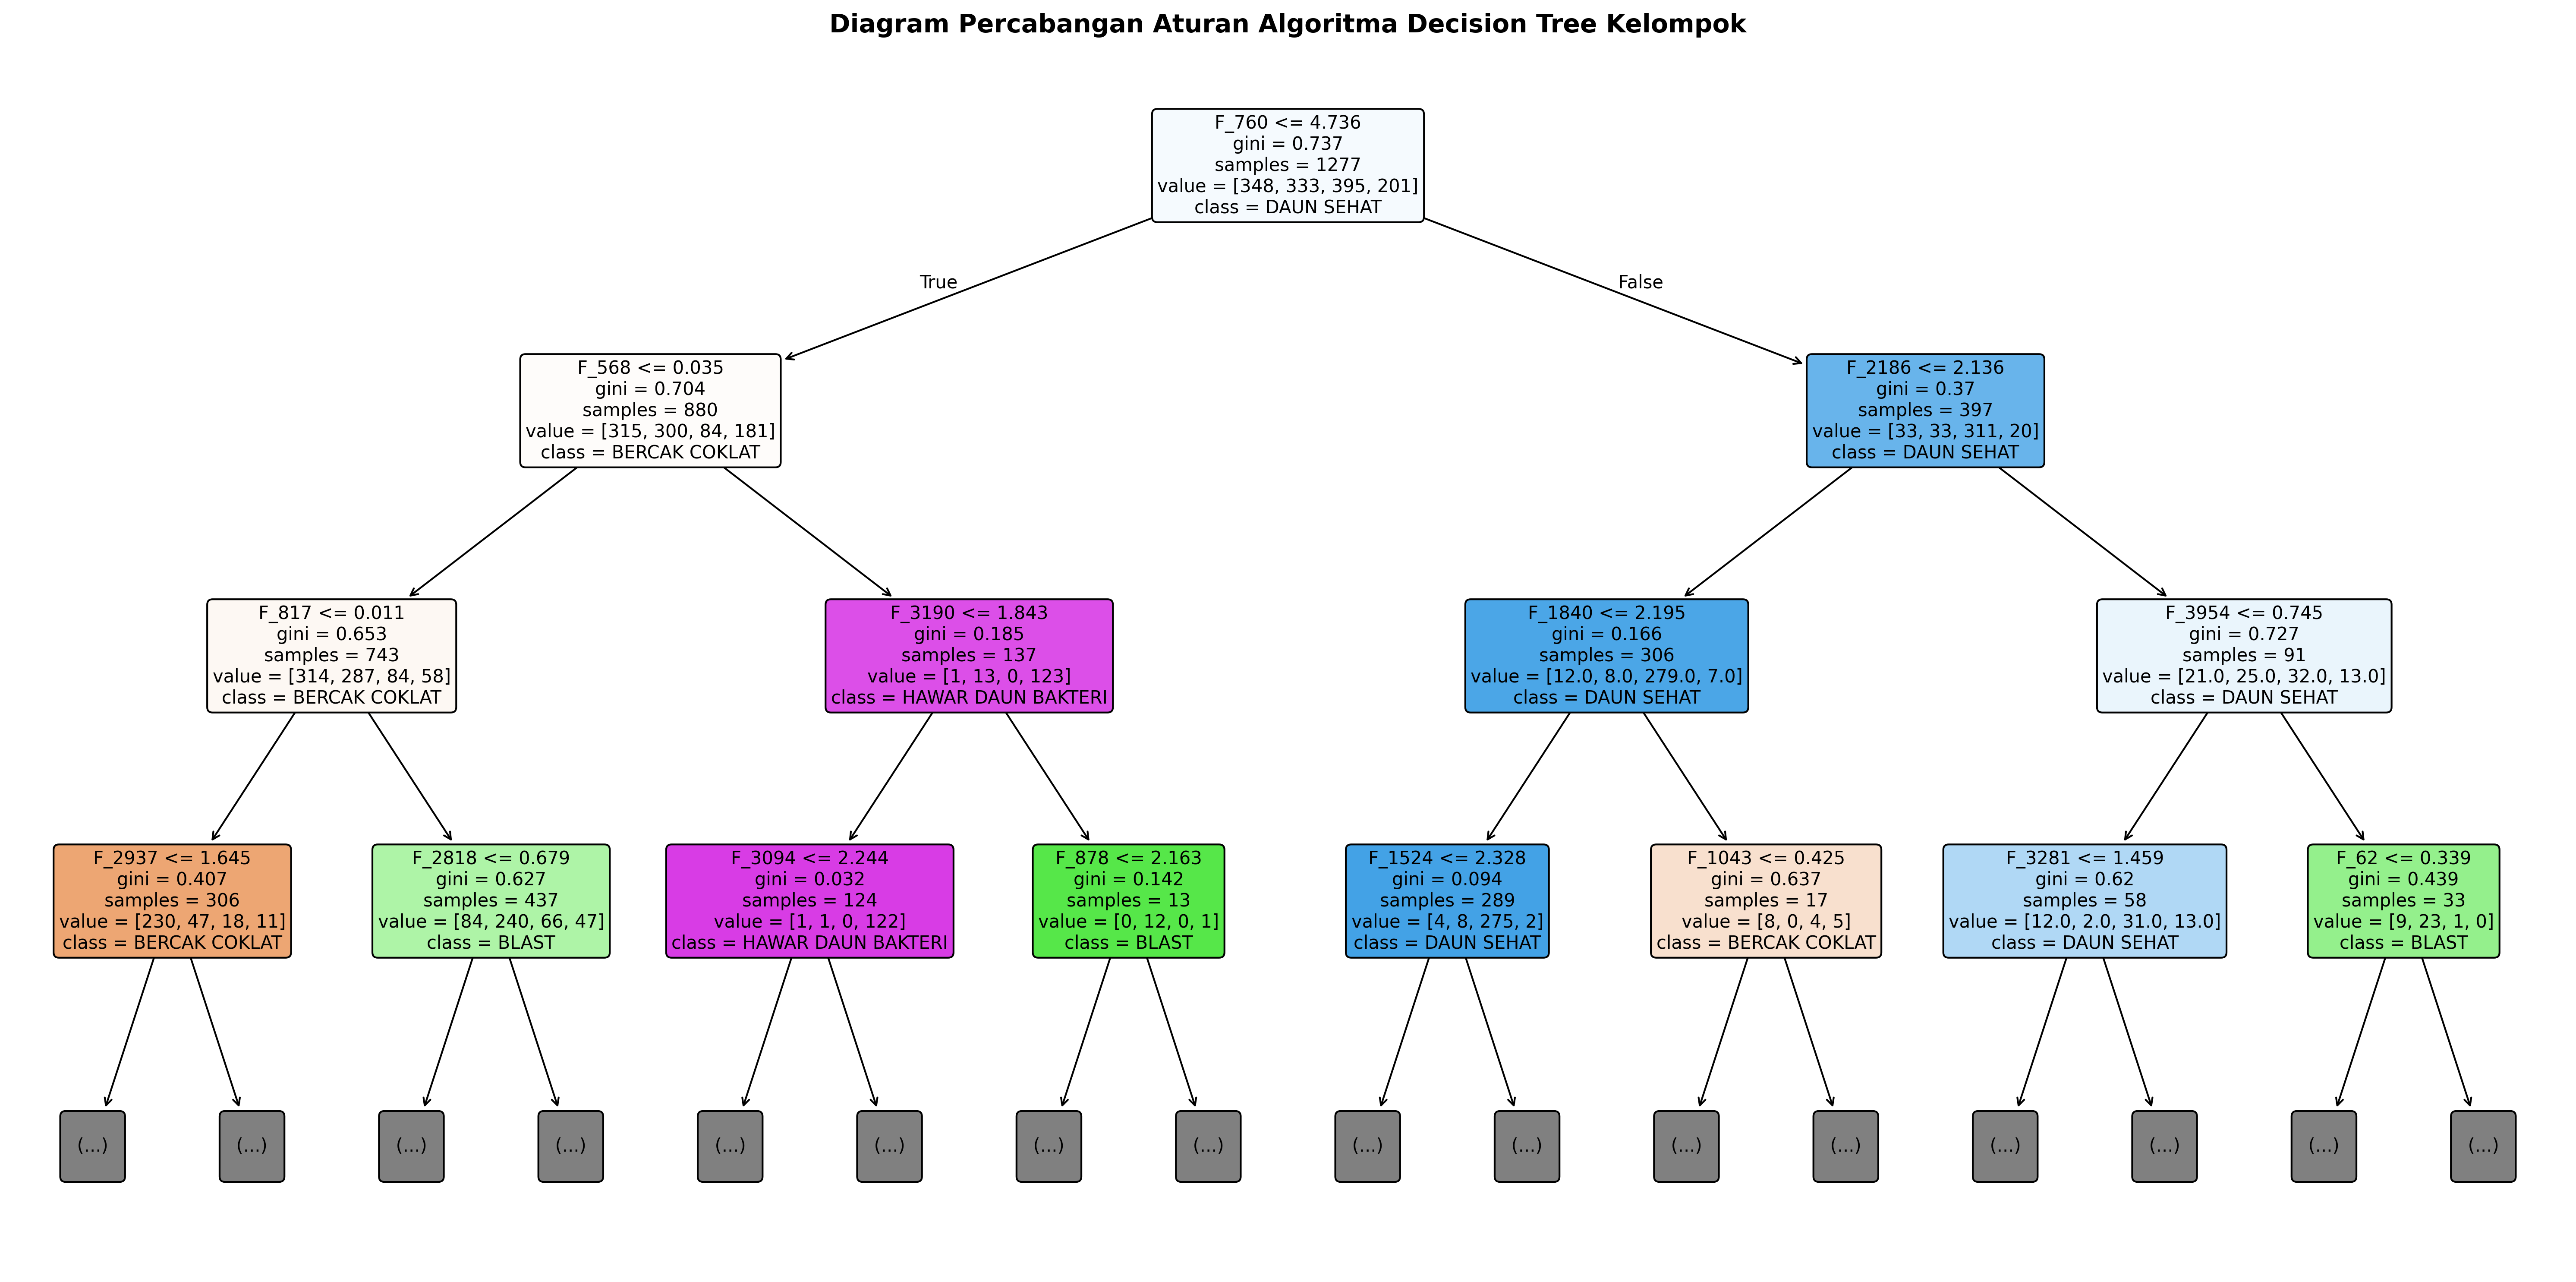

In [ ]:
# =========================================================
# #Visualisasi Decision Tree
# =========================================================
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

print("Sedang membuat grafik visualisasi Decision Tree...")

# Mengatur ukuran kanvas gambar grafik agar terlihat jelas
plt.figure(figsize=(20, 10), dpi=300)

# Menampilkan nama fitur secara ringkas untuk kebutuhan diagram
fitur_singkat = [f"F_{i+1}" for i in range(features.shape[1])]
CATEGORIES = ['BERCAK COKLAT', 'BLAST', 'DAUN SEHAT', 'HAWAR DAUN BAKTERI']

# Menggambar pohon keputusan
# max_depth=3 ditambahkan agar diagramnya rapi, terstruktur, dan tidak menumpuk padat
plot_tree(
    model_dt,
    max_depth=3,
    feature_names=fitur_singkat,
    class_names=CATEGORIES,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Diagram Percabangan Aturan Algoritma Decision Tree Kelompok", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== MEMBUAT GRAFIK VISUAL CONFUSION MATRIX ===


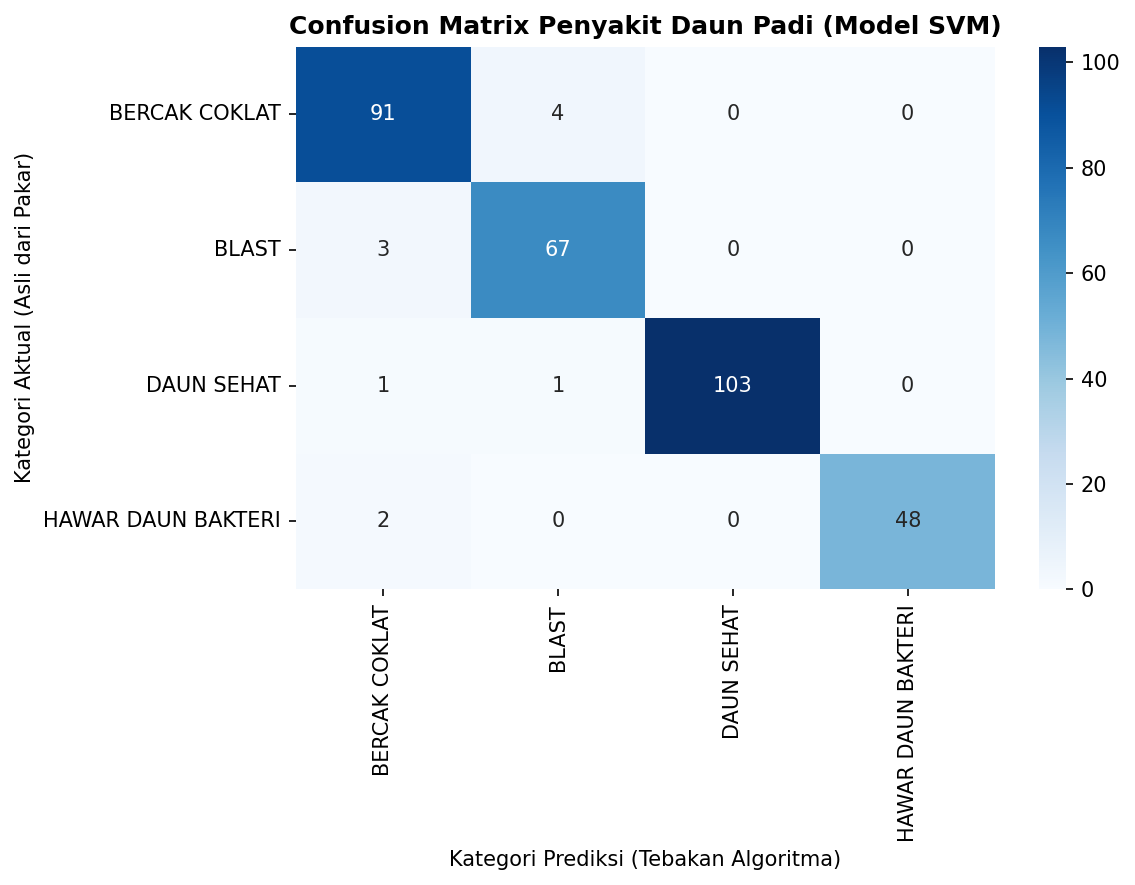

In [ ]:
# =========================================================
# EVALUASI 1: CONFUSION MATRIX (Model SVM)
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

CATEGORIES = ['BERCAK COKLAT', 'BLAST', 'DAUN SEHAT', 'HAWAR DAUN BAKTERI']

print("=== MEMBUAT GRAFIK VISUAL CONFUSION MATRIX ===")
# Menghitung matriks evaluasi dari hasil prediksi SVM
cm = confusion_matrix(y_test, pred_svm)

# Mengatur ukuran kanvas grafik
plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CATEGORIES, yticklabels=CATEGORIES)

plt.title('Confusion Matrix Penyakit Daun Padi (Model SVM)', fontsize=12, fontweight='bold')
plt.ylabel('Kategori Aktual (Asli dari Pakar)', fontsize=10)
plt.xlabel('Kategori Prediksi (Tebakan Algoritma)', fontsize=10)
plt.tight_layout()
plt.show()

=== MEMBUAT GRAFIK FEATURE IMPORTANCE ===


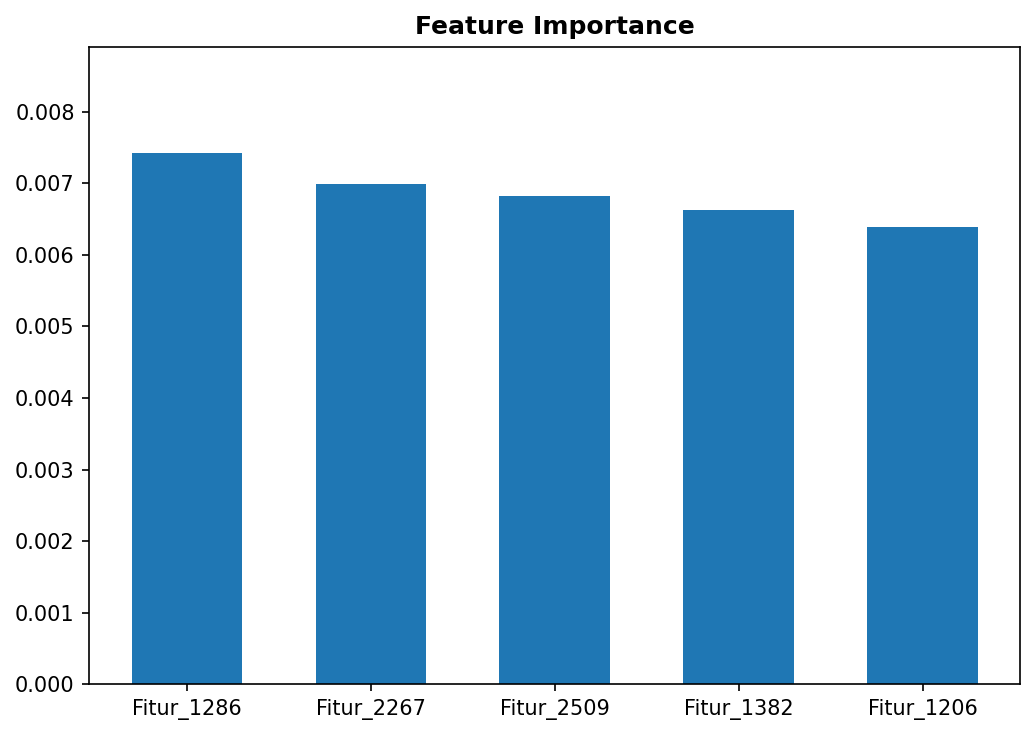

In [ ]:
# =========================================================
# EVALUASI 2: VISUALISASI FEATURE IMPORTANCE
# =========================================================
import numpy as np
import matplotlib.pyplot as plt

print("=== MEMBUAT GRAFIK FEATURE IMPORTANCE ===")
# Mengambil nilai tingkat kepentingan fitur dari Random Forest
importances = model_rf.feature_importances_
nama_kolom_fitur = [f"Fitur_{i+1}" for i in range(features.shape[1])]

# Ambil 5 fitur dengan nilai kepentingan tertinggi
indices = np.argsort(importances)[::-1][:5]

plt.figure(figsize=(7, 5), dpi=150)
plt.bar([nama_kolom_fitur[i] for i in indices], importances[indices], color='#1f77b4', width=0.6)

plt.title('Feature Importance', fontsize=12, fontweight='bold')
plt.ylim(0, max(importances[indices]) * 1.2) # Memberikan ruang di atas batang grafik
plt.tight_layout()
plt.show()

=== MEMBUAT GRAFIK PERBANDINGAN AKTUAL VS PREDIKSI ===


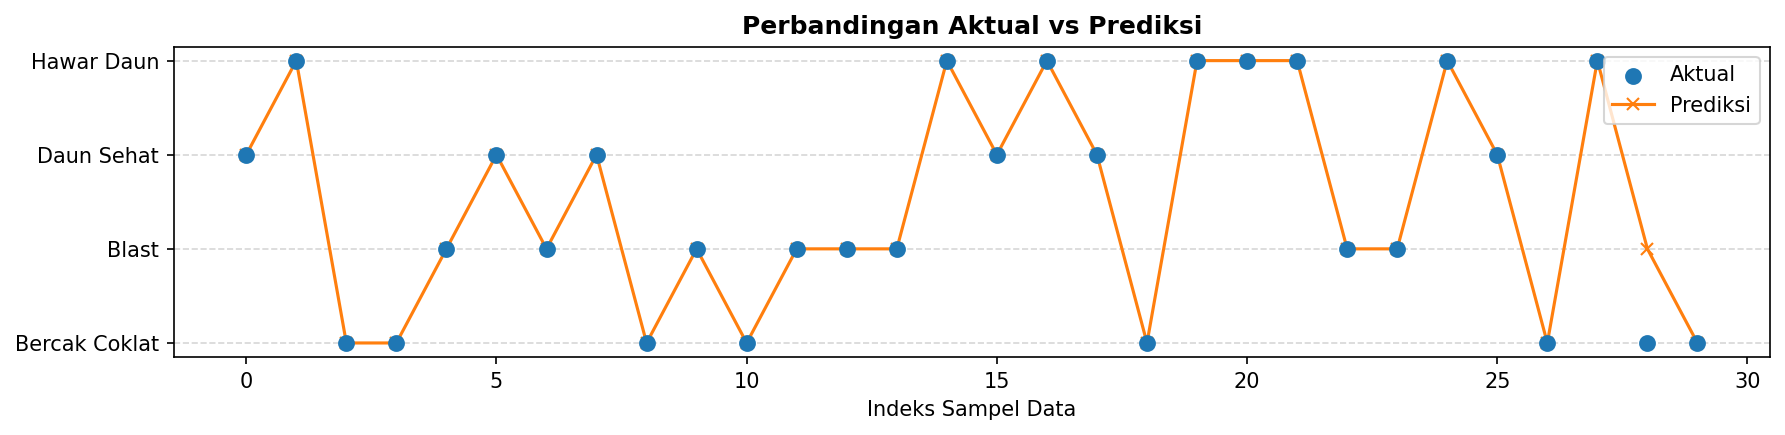

In [ ]:
# =========================================================
# EVALUASI 3: VISUALISASI PERBANDINGAN PREDIKSI VS AKTUAL
# =========================================================
import matplotlib.pyplot as plt

print("=== MEMBUAT GRAFIK PERBANDINGAN AKTUAL VS PREDIKSI ===")

# Mengambil sampel 30 data pertama agar plot grafik tidak terlalu padat
jumlah_sampel = 30
indeks_sumbu_x = range(jumlah_sampel)

plt.figure(figsize=(12, 3), dpi=150)

# 1. Plot data aktual sebagai titik lingkaran biru
plt.scatter(indeks_sumbu_x, y_test[:jumlah_sampel], color='#1f77b4', label='Aktual', s=50, zorder=5)

# 2. Plot hasil prediksi model (contoh: SVM) sebagai garis/penghubung oranye
plt.plot(indeks_sumbu_x, pred_svm[:jumlah_sampel], color='#ff7f0e', marker='x', label='Prediksi', linewidth=1.5)

# Mengatur tampilan sumbu label kategori (0=Bercak Coklat, 1=Blast, dst)
plt.yticks([0, 1, 2, 3], ['Bercak Coklat', 'Blast', 'Daun Sehat', 'Hawar Daun'])
plt.title('Perbandingan Aktual vs Prediksi', fontsize=12, fontweight='bold')
plt.xlabel('Indeks Sampel Data', fontsize=10)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()